In [13]:
import pickle
import math
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.spatial.transform import Rotation as R
from matplotlib.patches import Rectangle, Polygon
from hydrax.utils.files import get_data_path

# --- Setup Styling ---
mpl.rcParams["font.family"] = "serif"
mpl.rcParams["font.sans-serif"] = ["DejaVu Sans", "Arial", "Liberation Sans"]

sns.set_theme(font_scale=1.3,rc={
    "axes.facecolor": "white",   # inside axes
    "figure.facecolor": "white",  # outside axes
    'font.size':13,
    'font.family':'serif'
},)
# --- Helper Functions ---

def get_yaw_from_quat(quat_wxyz):
    """Robustly converts wxyz quaternion to yaw using scipy."""
    quat_xyzw = [quat_wxyz[1], quat_wxyz[2], quat_wxyz[3], quat_wxyz[0]]
    r = R.from_quat(quat_xyzw)
    return r.as_euler('xyz')[2]

def rotmat(yaw):
    c, s = math.cos(yaw), math.sin(yaw)
    return np.array([[c, -s], [s, c]])

def t_shape_polys(x, y, yaw, stem_w=0.05, stem_h=0.1, head_w=0.1, head_h=0.05):
    """Calculates T-shape geometry for plotting."""
    offset = np.array([0.0425, 0.0])
    R_mat = rotmat(yaw)
    
    stem_center = (np.array([0.0, -head_h / 2.0]) @ R_mat.T) + np.array([x, y]) + offset
    head_center = (np.array([0.0,  stem_h / 2.0]) @ R_mat.T) + np.array([x, y]) + offset
    
    def get_corners(center, w, h):
        hw, hh = w/2, h/2
        local = np.array([[-hw, -hh], [hw, -hh], [hw, hh], [-hw, hh]])
        return (local @ R_mat.T) + center

    return get_corners(stem_center, stem_w, stem_h), get_corners(head_center, head_w, head_h)

def draw_t(ax, x, y, yaw, **kwargs):
    stem_poly, head_poly = t_shape_polys(x, y, yaw)
    ax.add_patch(Polygon(stem_poly, closed=True, **kwargs))
    ax.add_patch(Polygon(head_poly, closed=True, **kwargs))

# --- Data Loading and Processing ---


seeds = [40, 41, 42, 43, 44, 45]
algos = ["mppi", "cem", "ps", "mtp"]
target_steps = 80
cutoff_at_step = 60 

all_data = {}
all_data["joint"] = {}
all_data["free"] = {}
all_data["joint_long"] = {}
all_data["free_long"] = {}

for model in ["free", "joint", "free_long", "joint_long"]:
    
    for seed in seeds:
        all_data[model][seed] = {}
        for algo in algos:
            all_data[model][seed][algo] = {}
            
            path = get_data_path() / "pushT_sim_sweep" / f"{model}" / f"seed_{seed}_{algo}.pkl"
            
            with open(path, "rb") as f:
                raw_data = pickle.load(f)
            
            # 1. Initial Subsampling
            indices = np.linspace(0, len(raw_data) - 1, min(len(raw_data), target_steps), dtype=int)
            subsampled = [raw_data[i] for i in indices]
            
            # 2. Apply Cutoff (If specified)
            if cutoff_at_step is not None:
                subsampled = subsampled[:cutoff_at_step]
            
            processed = {
                'qpos': [],   
                'state_error': [], 
                'success': []   
            }
            
            for d in subsampled:
                processed['qpos'].append(d['qpos'])
                processed['state_error'].append(d['state_error'])
                processed['success'].append(d['success'])
                
            all_data[model][seed][algo] = processed

# --- Combined Visualization (Seed 100 example) ---

In [14]:

init_pose = []
for seed in seeds:
    init_pose.append(all_data["joint"][seed]["mppi"]["qpos"][0][:3])
    
init_pose = np.array(init_pose)
print(init_pose.shape)

joint_success = {}
joint_long_success = {}
free_success = {}
free_long_success = {}

for algo in algos:
    for seed in seeds:
        joint_success[seed] = all_data["joint"][seed][algo]["success"]
        free_success[seed] = all_data["free"][seed][algo]["success"]
        joint_long_success[seed] = all_data["joint_long"][seed][algo]["success"]
        free_long_success[seed] = all_data["free_long"][seed][algo]["success"]
        
        
        
final_state_error_joint = np.empty((len(seeds), len(algos)))
final_state_error_free = np.empty((len(seeds), len(algos)))
final_state_error_joint_long = np.empty((len(seeds), len(algos)))
final_state_error_free_long = np.empty((len(seeds), len(algos)))

for i, algo in enumerate(algos):
    for j, seed in enumerate(seeds):
        final_state_error_joint[j, i] = all_data["joint"][seed][algo]["state_error"][-1]
        final_state_error_free[j, i] = all_data["free"][seed][algo]["state_error"][-1]
        final_state_error_joint_long[j, i] = all_data["joint_long"][seed][algo]["state_error"][-1]
        final_state_error_free_long[j, i] = all_data["free_long"][seed][algo]["state_error"][-1]


algo_labels = ["MPPI", "CEM", "PS", "MTP"]
palette = sns.color_palette("deep", n_colors=len(algo_labels))  # seaborn default look [web:29][web:30]
palette = [palette[2], palette[1], palette[3], palette[0]]  # reorder to match algo_labels
algo_colors = dict(zip(algo_labels, palette))


(6, 3)


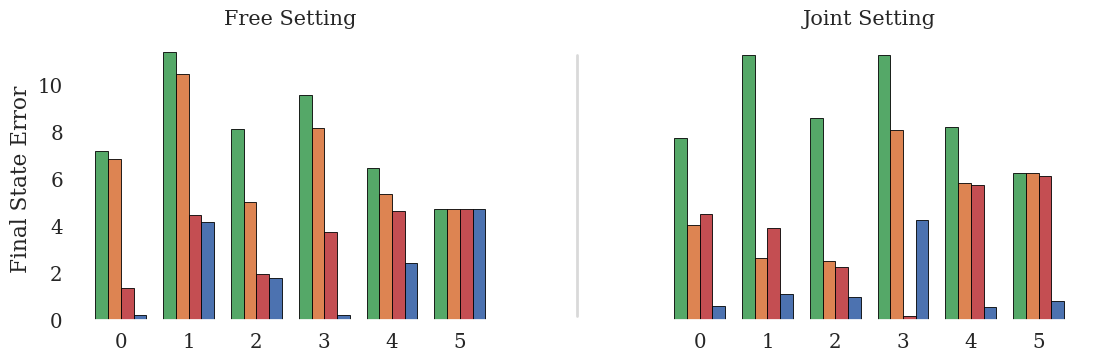

In [25]:
err_free  = final_state_error_free
err_joint = final_state_error_joint

n_seeds = len(seeds)
n_algos = len(algo_labels)

group_gap  = 0.6
group_step = 1.0 + group_gap
x = np.arange(n_seeds) * group_step

width   = 0.3
offsets = (np.arange(n_algos) - (n_algos - 1) / 2) * width

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(13, 4.2), sharey=True)

def plot_grouped(ax, err, panel_title):
    for j, name in enumerate(algo_labels):
        ax.bar(
            x + offsets[j],
            err[:, j],
            width,
            label=name,
            color=algo_colors[name],
            edgecolor="black",
            linewidth=0.6,
        )
    ax.set_xticks(x)
    ax.set_xticklabels([f"{s-40}" for s in seeds])
    ax.set_title(panel_title, fontsize=15, pad=10)
    ax.grid(axis="y", alpha=0.25)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plot_grouped(ax0, err_free,  "Free Setting")
plot_grouped(ax1, err_joint, "Joint Setting")

ax0.set_ylabel("Final State Error")
# ax1.set_ylabel("Final State Error")

# Visually separate panels: more whitespace between subplots. [web:17]
fig.subplots_adjust(wspace=0.35, top=0.78)

# Optional: a subtle divider in the middle (emphasizes two experiments).
fig.add_artist(plt.Line2D([0.51, 0.51], [0.12, 0.74],
                          transform=fig.transFigure, color="0.85", lw=2))


plt.show()
# fig.savefig("fr3_sim_sweep_final_error.pdf", bbox_inches="tight")


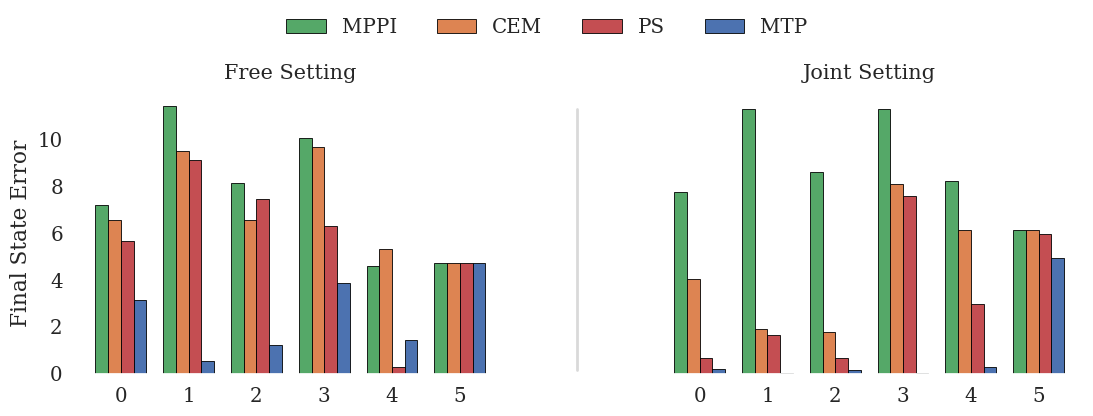

In [19]:
err_free  = final_state_error_free_long
err_joint = final_state_error_joint_long
    
n_seeds = len(seeds)
n_algos = len(algo_labels)

group_gap  = 0.6
group_step = 1.0 + group_gap
x = np.arange(n_seeds) * group_step

width   = 0.3
offsets = (np.arange(n_algos) - (n_algos - 1) / 2) * width

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(13, 4.2), sharey=True)

def plot_grouped(ax, err, panel_title):
    for j, name in enumerate(algo_labels):
        ax.bar(
            x + offsets[j],
            err[:, j],
            width,
            label=name,
            color=algo_colors[name],
            edgecolor="black",
            linewidth=0.6,
        )
    ax.set_xticks(x)
    ax.set_xticklabels([f"{s-40}" for s in seeds])
    ax.set_title(panel_title, fontsize=15, pad=10)
    ax.grid(axis="y", alpha=0.25)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plot_grouped(ax0, err_free,  "Free Setting")
plot_grouped(ax1, err_joint, "Joint Setting")

ax0.set_ylabel("Final State Error")

# Visually separate panels: more whitespace between subplots. [web:17]
fig.subplots_adjust(wspace=0.35, top=0.78)

# One shared legend for the whole figure. [web:2][web:4]
handles, labels = ax0.get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=n_algos, frameon=False)

# Optional: a subtle divider in the middle (emphasizes two experiments).
fig.add_artist(plt.Line2D([0.51, 0.51], [0.12, 0.74],
                          transform=fig.transFigure, color="0.85", lw=2))


plt.show()
# save as pdf
fig.savefig("fr3_sim_sweep_final_error_long.pdf", bbox_inches="tight")

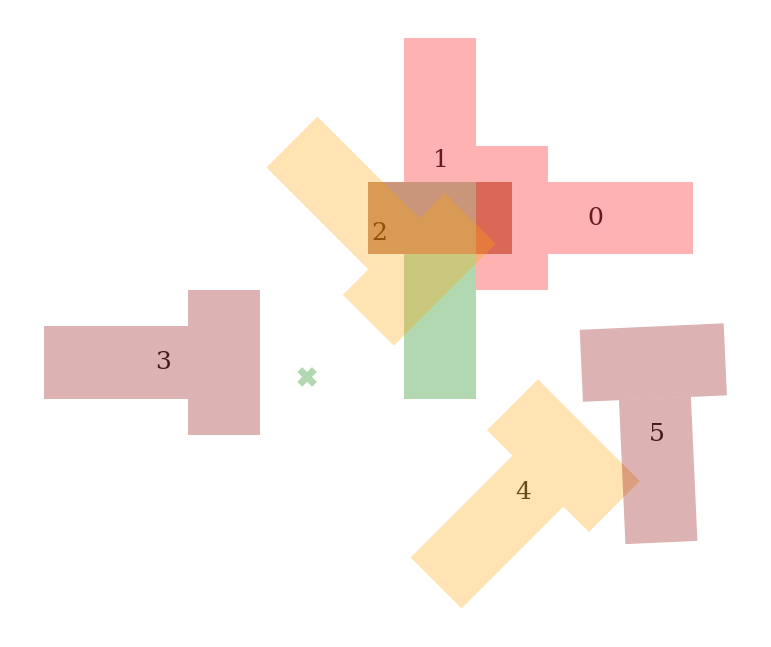

In [27]:
fig, ax1 = plt.subplots(1, 1, figsize=(16, 7))

colorcode = {
    40: "red",
    41: "red",
    42: "orange",
    43: "darkred",
    44: "orange",
    45: "darkred",
}
labels_pos = {
    40: (0.65, 0.61),
    41: (0.543, 0.65),
    42: (0.5, 0.6),
    43: (0.35, 0.51),
    44: (0.6, 0.42),
    45: (0.693, 0.46),
}
ax1.scatter(0.45, 0.5, color="green", alpha=0.3, edgecolor='none', zorder=10, marker='X', s=200)
draw_t(ax1, .5, 0.56, 0.0, 
           facecolor="green", alpha=0.3, edgecolor='none', zorder=10)

for i in range(0, len(seeds)):
    # Applied your -pi/2 yaw correction
    draw_t(ax1, -init_pose[i][1] + .5, init_pose[i][0] + 0.6, init_pose[i][2], 
           facecolor=colorcode[seeds[i]], alpha=0.3, edgecolor='none', zorder=10)
    # label
    ax1.text(labels_pos[seeds[i]][0], labels_pos[seeds[i]][1], f"{seeds[i]-40}", fontsize=18, ha='center', va='center')

ax1.set_aspect('equal')
plt.tight_layout()
sns.despine(ax=ax1)
ax1.grid(False)
ax1.set_yticks([])  
ax1.set_xticks([])  

# save as pdf
plt.savefig("fr3_sim_sweep_poses.pdf", bbox_inches='tight')
